# Laplacian Eigenmaps on Synthetic Graphs



In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

np.random.seed(7)

In [2]:
def laplacian_eigenmap_embedding(G, n_components=2, normalized=False, tol=1e-10):
    """Return non-trivial Laplacian Eigenmaps embedding for graph G."""
    A = nx.to_numpy_array(G, dtype=float)
    degrees = A.sum(axis=1)
    D = np.diag(degrees)
    L = D - A

    if normalized:
        with np.errstate(divide="ignore"):
            inv_sqrt_deg = np.where(degrees > 0, 1.0 / np.sqrt(degrees), 0.0)
        D_inv_sqrt = np.diag(inv_sqrt_deg)
        L = D_inv_sqrt @ L @ D_inv_sqrt

    eigvals, eigvecs = np.linalg.eigh(L)
    order = np.argsort(eigvals)
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    nontrivial = np.where(eigvals > tol)[0]
    if len(nontrivial) < n_components:
        raise ValueError("Not enough non-trivial eigenvectors; check graph connectivity.")

    idx = nontrivial[:n_components]
    return eigvals[idx], eigvecs[:, idx]

In [3]:
graphs = {
    "Path graph (n=20)": nx.path_graph(20),
    "Cycle graph (n=20)": nx.cycle_graph(20),
    "Star graph (n=20)": nx.star_graph(19),
    "Two-community SBM": nx.stochastic_block_model(
        [15, 15],
        [[0.75, 0.04], [0.04, 0.75]],
        seed=7,
    ),
}

for name, G in graphs.items():
    print(f"{name}: nodes={G.number_of_nodes()}, edges={G.number_of_edges()}")

Path graph (n=20): nodes=20, edges=19
Cycle graph (n=20): nodes=20, edges=20
Star graph (n=20): nodes=20, edges=19
Two-community SBM: nodes=30, edges=162


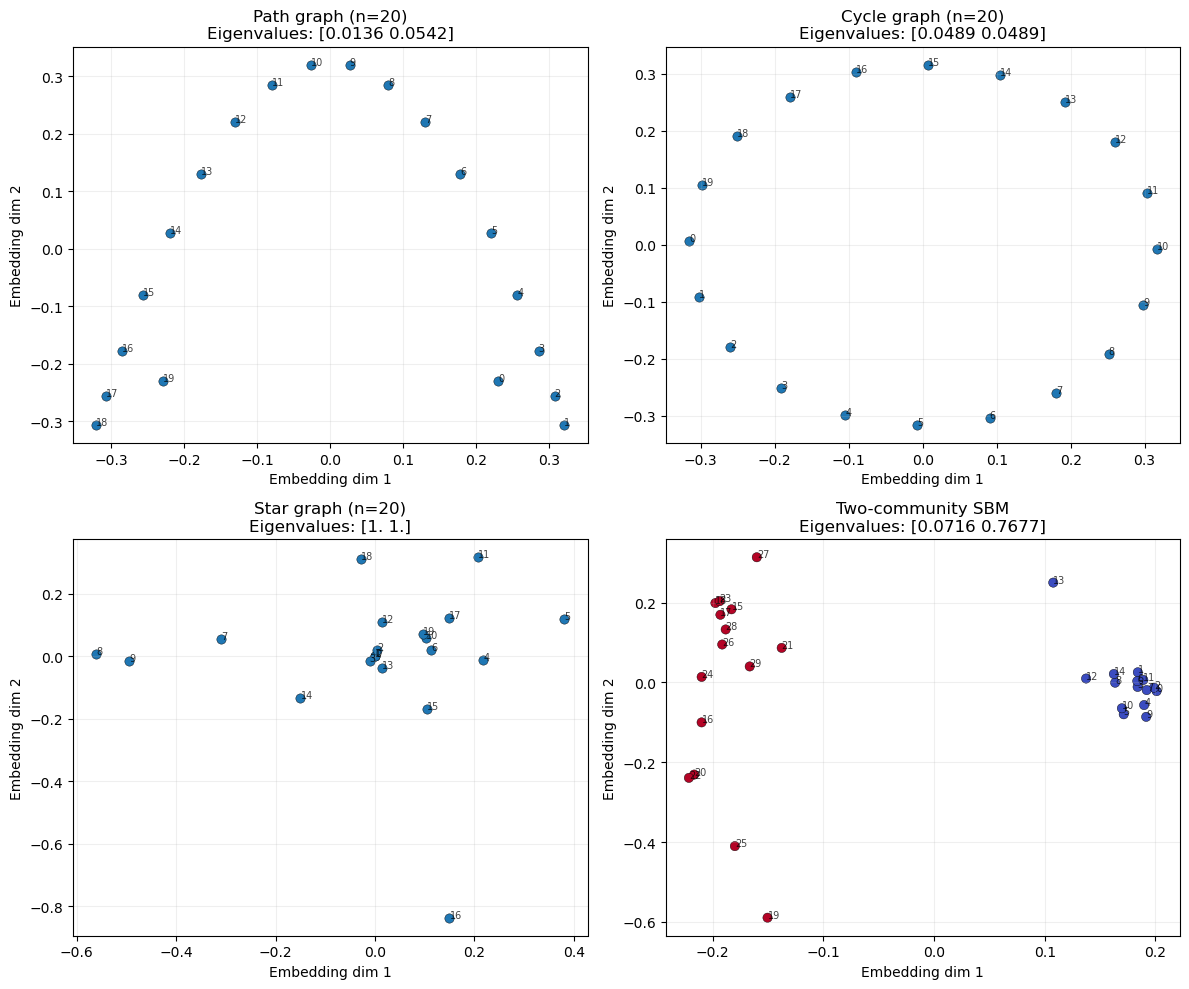

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (name, G) in zip(axes.flat, graphs.items()):
    eigvals, Z = laplacian_eigenmap_embedding(G, n_components=2, normalized=True)

    if name == "Two-community SBM":
        colors = np.array([0] * 15 + [1] * 15)
        scatter = ax.scatter(Z[:, 0], Z[:, 1], c=colors, cmap="coolwarm", s=45, edgecolor="k", linewidth=0.3)
    else:
        scatter = ax.scatter(Z[:, 0], Z[:, 1], color="tab:blue", s=45, edgecolor="k", linewidth=0.3)

    for i, (x, y) in enumerate(Z):
        ax.text(x, y, str(i), fontsize=7, alpha=0.75)

    ax.set_title(f"{name}\nEigenvalues: {eigvals.round(4)}")
    ax.set_xlabel("Embedding dim 1")
    ax.set_ylabel("Embedding dim 2")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

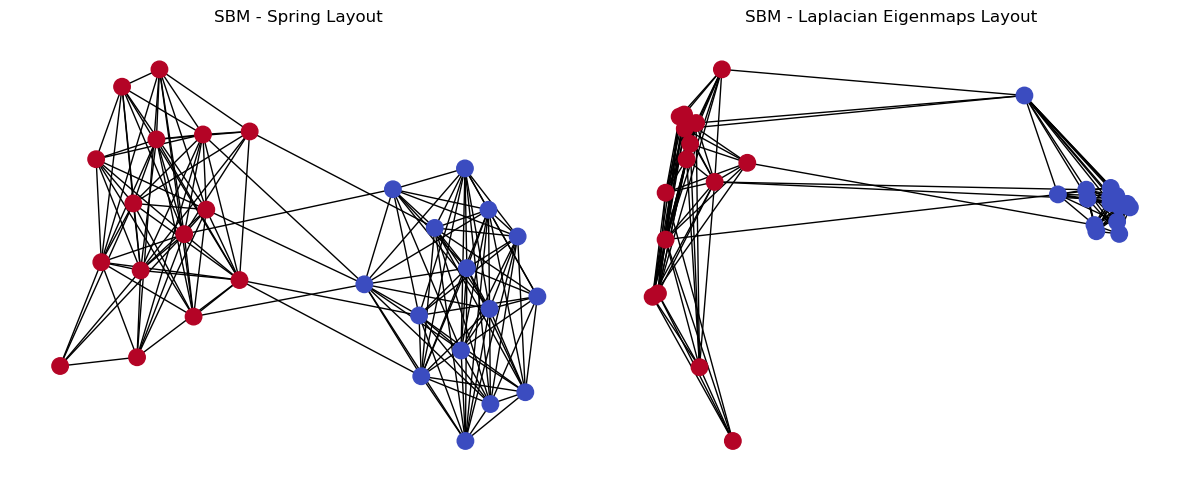

In [5]:
# Compare SBM graph layouts: spring layout vs Laplacian Eigenmaps layout
G_sbm = graphs["Two-community SBM"]
_, Z_sbm = laplacian_eigenmap_embedding(G_sbm, n_components=2, normalized=True)
colors = np.array([0] * 15 + [1] * 15)

pos_spring = nx.spring_layout(G_sbm, seed=7)
pos_le = {i: Z_sbm[i] for i in range(G_sbm.number_of_nodes())}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
nx.draw_networkx(
    G_sbm,
    pos=pos_spring,
    node_color=colors,
    cmap="coolwarm",
    node_size=140,
    with_labels=False,
    ax=axes[0],
)
axes[0].set_title("SBM - Spring Layout")

nx.draw_networkx(
    G_sbm,
    pos=pos_le,
    node_color=colors,
    cmap="coolwarm",
    node_size=140,
    with_labels=False,
    ax=axes[1],
)
axes[1].set_title("SBM - Laplacian Eigenmaps Layout")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [6]:
# Simple quantitative check: within-community vs between-community distances in SBM embedding
def mean_pairwise_distance(points):
    n = len(points)
    if n < 2:
        return 0.0
    total = 0.0
    count = 0
    for i in range(n):
        for j in range(i + 1, n):
            total += np.linalg.norm(points[i] - points[j])
            count += 1
    return total / count

community_0 = Z_sbm[:15]
community_1 = Z_sbm[15:]
within_0 = mean_pairwise_distance(community_0)
within_1 = mean_pairwise_distance(community_1)
between = np.mean([np.linalg.norm(a - b) for a in community_0 for b in community_1])

print(f"Within community 0 distance: {within_0:.4f}")
print(f"Within community 1 distance: {within_1:.4f}")
print(f"Between community distance:  {between:.4f}")
print("Separation ratio (between / avg within):", round(between / ((within_0 + within_1) / 2), 4))

Within community 0 distance: 0.0812
Within community 1 distance: 0.2884
Between community distance:  0.4368
Separation ratio (between / avg within): 2.3639
